**Импорт необходимых библиотек**

In [166]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

In [167]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, precision_recall_curve
import joblib
import warnings
warnings.filterwarnings('ignore')

**Загружаем данные**

In [168]:
dataset = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

**Первичный осмотр данных**

In [169]:
print(f"Размер датасета: {dataset.shape}")
print(f"\nПервые 5 строк:\n{dataset.head()}")
print(f"\nИнформация о типах данных:\n{dataset.info()}")
print(f"\nПропущенные значения:\n{dataset.isnull().sum()}")
print(f"\nЦелевая переменная (Churn):\n{dataset['Churn'].value_counts(normalize=True)}")

Размер датасета: (7043, 21)

Первые 5 строк:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport Str

***Графики***

**График №1: Распределение Churn (целевая переменная)**

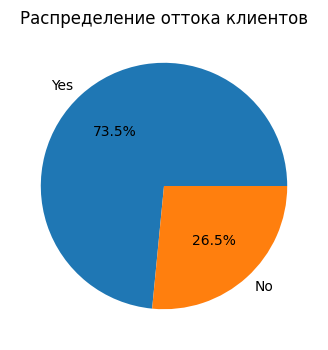

In [170]:
plt.figure(figsize=(6, 4))
dataset['Churn'].value_counts().plot(kind='pie', autopct='%1.1f%%',  labels=['Yes','No'])
plt.title('Распределение оттока клиентов')
plt.ylabel('')
plt.show()

**График №2: Отток по типу контракта**

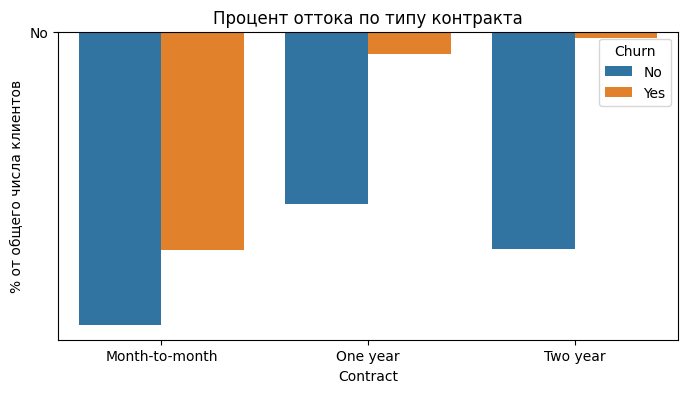

In [171]:
plt.figure(figsize=(8, 4))
sns.barplot(x='Contract', y='Churn', hue='Churn', data=dataset, estimator= lambda x: len(x) / len(dataset))
plt.title('Процент оттока по типу контракта')
plt.ylabel('% от общего числа клиентов')
plt.show()

**График 3: Корреляция числовых признаков с целевой переменной**

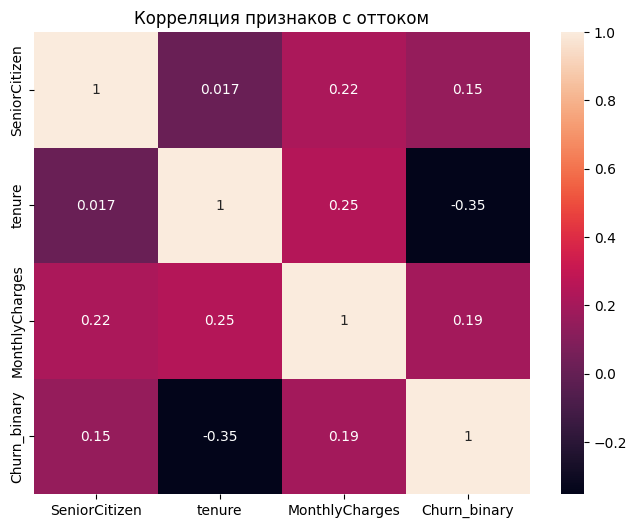

In [172]:
tmp_dataset = dataset.copy()
tmp_dataset['Churn_binary'] = tmp_dataset['Churn'].map({'No': 0, 'Yes': 1})
numeric_col = tmp_dataset.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = tmp_dataset[numeric_col].corr()['Churn_binary'].sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.heatmap(tmp_dataset[numeric_col].corr(), annot=True)
plt.title('Корреляция признаков с оттоком')
plt.show()

**График 4: Boxplot месячных платежей по факту оттока**

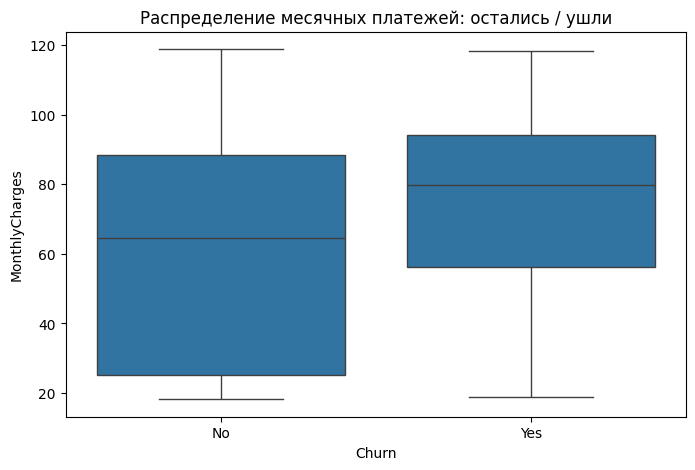

In [173]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=dataset)
plt.title('Распределение месячных платежей: остались / ушли')
plt.show()

**Подготавливаем данные к обучению**

In [174]:
from src.preprocess import load_and_clean, encode_target, encode_categorical, prepare_features

df = load_and_clean('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df = encode_target(df)

cat_cols = df.select_dtypes(include=['object']).columns.tolist()
if 'Churn' in cat_cols:
    cat_cols.remove('Churn')

df_encoded, encoders = encode_categorical(df, cat_cols)

numeric_cols = df_encoded.select_dtypes(include=[np.number]).columns.tolist()
df_encoded[numeric_cols] = df_encoded[numeric_cols].fillna(df_encoded[numeric_cols].median())

#Заполним категориальные признаки модой
object_cols = df_encoded.select_dtypes(include=['object']).columns.tolist()
for col in object_cols:
    df_encoded[col] = df_encoded[col].fillna(df_encoded[col].mode()[0])

df_encoded.to_csv('../data/processed/cleaned_data.csv', index=False)

X, y, scaler = prepare_features(df_encoded)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

**Обучение и оценка моделей**

In [175]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
    print(f"\n{name}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    roc_auc = roc_auc_score(y_test, y_proba)
    
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))
    
    results.append({'model': name, 'roc_auc': roc_auc})

results_df = pd.DataFrame(results).sort_values('roc_auc', ascending=False)
print("\nРейтинг моделей по ROC-AUC:")
print(results_df)


Logistic Regression
ROC-AUC: 0.8402
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.87      1035
       Churn       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409


Random Forest
ROC-AUC: 0.8218
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.86      1035
       Churn       0.64      0.51      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.79      1409


Gradient Boosting
ROC-AUC: 0.8449
              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.67      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75  

**Сохранение артефактов**

In [176]:
import joblib

best_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
best_model.fit(X_train, y_train)

joblib.dump(best_model, '../models/best_model.pkl')
joblib.dump(encoders, '../models/encoders.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

['../models/scaler.pkl']